Month
August        84225
July         120541
November     280753
October       78256
September     71597
Name: Cost, dtype: int64 Ad Group
Shop - 1:1 - Desk - [shop coupon code]             41194
Shop - 1:1 - Desk - [shop coupon]                  69198
Shop - 1:1 - Desk - [shop discount code]            8605
Shop - 1:1 - Desk - [shop promo code]              81485
Shop - 1:1 - Desk - [shop promo]                    2474
Shop - 1:1 - Mob - [shop coupon code]              59272
Shop - 1:1 - Mob - [shop coupon]                   91497
Shop - 1:1 - Mob - [shop discount code]            12726
Shop - 1:1 - Mob - [shop promo code]               93570
Shop - 1:1 - Mob - [shop promo]                     2634
Shop - Exact - Desk - Black Friday/Cyber Monday        3
Shop - Exact - Desk - Competitor                     932
Shop - Exact - Desk - Coupon Code                  14709
Shop - Exact - Desk - Discount Code                 3464
Shop - Exact - Desk - Free Shipping                  362
Shop 

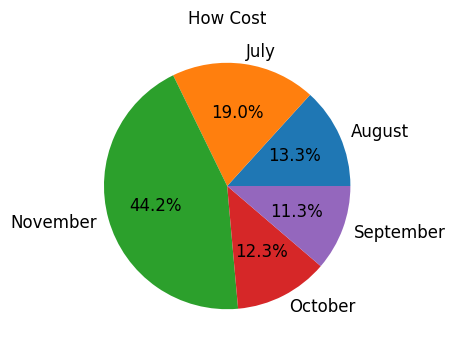

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('C:\\python_projects\\ML_DL\\shop.csv')

cost_by_group=df.groupby('Ad Group')['Cost'].sum()
cost_by_mounth=df.groupby('Month')['Cost'].sum()

print(cost_by_mounth,cost_by_group)

plt.figure(figsize=(4,4), dpi=100)
plt.pie(cost_by_mounth, labels=cost_by_mounth.index, autopct='%1.1f%%',textprops={'fontsize': 12})
plt.title('How Cost')

plt.show()

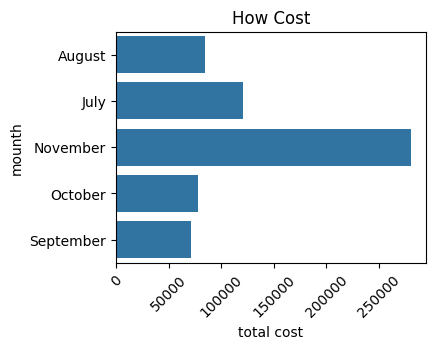

In [66]:
import seaborn as sns

plt.figure(figsize=(4,3),dpi=100)
sns.barplot(x=cost_by_mounth.values,y=cost_by_mounth.index,orient='h')
plt.title('How Cost')
plt.xlabel('total cost')
plt.ylabel('mounth')
plt.xticks(rotation=45)
plt.show()


                                   Ad Group      Month   Cost
0    Shop - 1:1 - Desk - [shop coupon code]     August   6123
1    Shop - 1:1 - Desk - [shop coupon code]       July   6669
2    Shop - 1:1 - Desk - [shop coupon code]   November  18641
3    Shop - 1:1 - Desk - [shop coupon code]    October   4812
4    Shop - 1:1 - Desk - [shop coupon code]  September   4949
..                                      ...        ...    ...
185              Shop - Phrase - Mob - Sale     August    401
186              Shop - Phrase - Mob - Sale       July    981
187              Shop - Phrase - Mob - Sale   November    376
188              Shop - Phrase - Mob - Sale    October    226
189              Shop - Phrase - Mob - Sale  September    231

[190 rows x 3 columns]


<Axes: xlabel='Month', ylabel='Cost'>

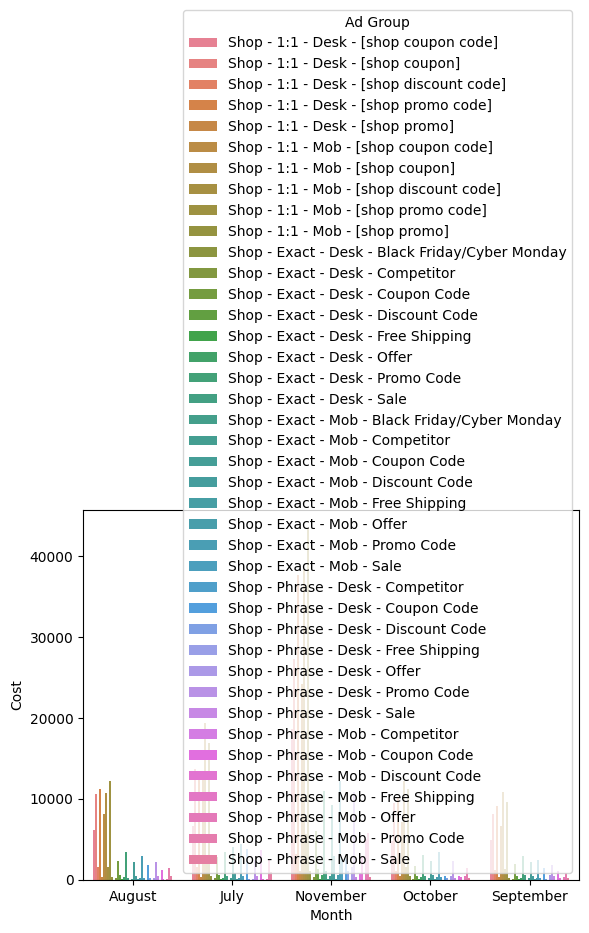

In [43]:
cost_by_group_month=df.groupby(['Ad Group','Month'])['Cost'].sum().reset_index()
print(cost_by_group_month)
plt.Figure(figsize=(4,4),dpi=100)
sns.barplot(x='Month',y='Cost',hue='Ad Group',data=cost_by_group_month)

Month                                             August     July  November  \
Ad Group                                                                      
Shop - 1:1 - Desk - [shop coupon code]            6123.0   6669.0   18641.0   
Shop - 1:1 - Desk - [shop coupon]                10586.0  13746.0   27336.0   
Shop - 1:1 - Desk - [shop discount code]          1571.0   1606.0    3182.0   
Shop - 1:1 - Desk - [shop promo code]            11235.0  13278.0   37729.0   
Shop - 1:1 - Desk - [shop promo]                   343.0    391.0    1039.0   
Shop - 1:1 - Mob - [shop coupon code]             8146.0  13157.0   24149.0   
Shop - 1:1 - Mob - [shop coupon]                 10713.0  19371.0   38273.0   
Shop - 1:1 - Mob - [shop discount code]           1590.0   2637.0    5651.0   
Shop - 1:1 - Mob - [shop promo code]             12262.0  16946.0   43542.0   
Shop - 1:1 - Mob - [shop promo]                    347.0    485.0    1118.0   
Shop - Exact - Desk - Black Friday/Cyber Monday     

<Axes: xlabel='Ad Group'>

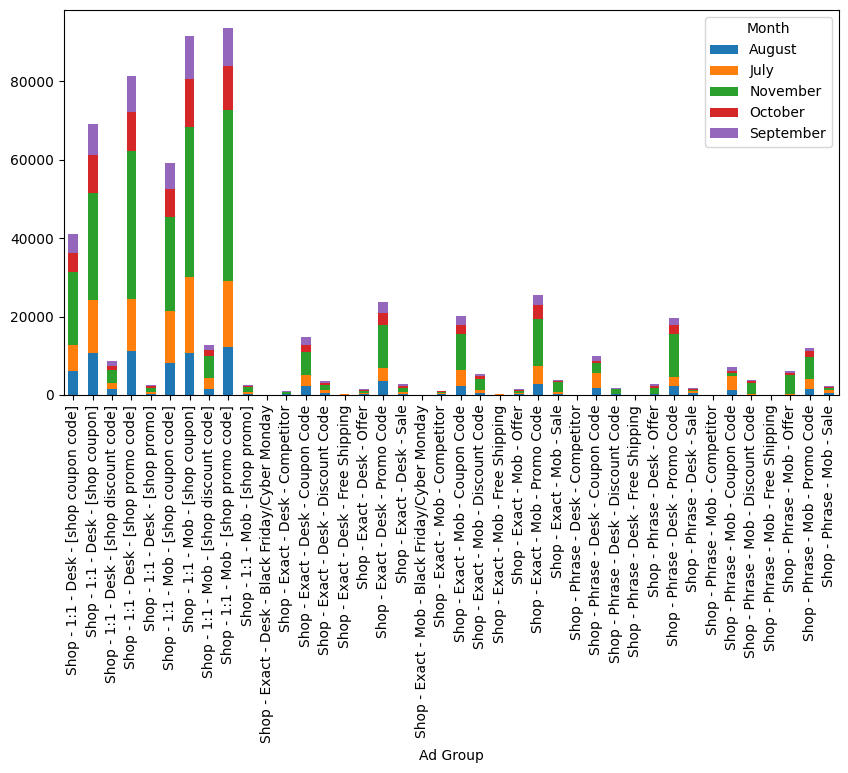

In [44]:
cost_by_group_month_a=df.groupby(['Ad Group','Month'])['Cost'].sum().unstack()
print(cost_by_group_month_a)
cost_by_group_month_a.plot(kind='bar',stacked=True,figsize=(10,5))


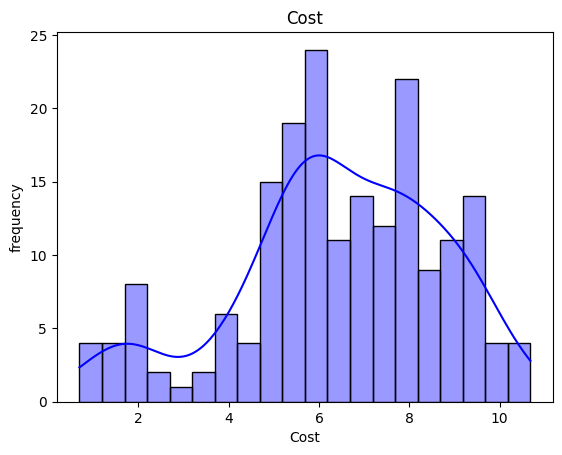

count      190.000000
mean      3344.063158
std       6524.606753
min          1.000000
25%        188.500000
50%        563.500000
75%       2967.000000
max      43542.000000
Name: Cost, dtype: float64

In [71]:
sns.histplot(np.log1p(df['Cost']),bins=20,color='b',kde=True,alpha=0.4)
plt.title('Cost')
plt.ylabel('frequency')
plt.show()
df['Cost'].describe()


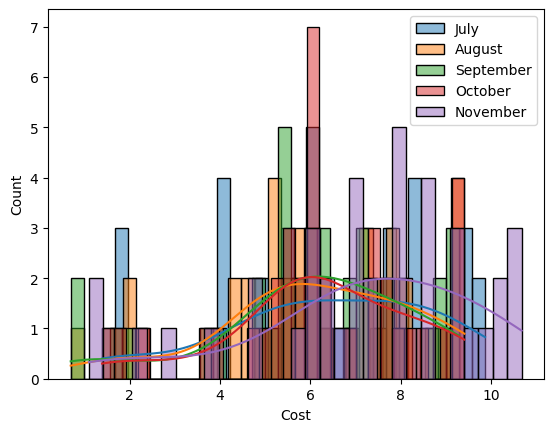

In [ ]:
Monthds=df['Month'].unique()

for i in Monthds[0:5]:
    sns.histplot(np.log1p(df[df['Month']==i]['Cost']),bins=30,kde=True,alpha=0.5,label=i)
plt.legend()
plt.show()

In [17]:
Monthds=df['Month'].unique()
for ii in Monthds:
    sns.boxplot(x=ii,y='Sale Amount',data=df)

plt.show()

ValueError: Could not interpret value `July` for `x`. An entry with this name does not appear in `data`.

143885.285


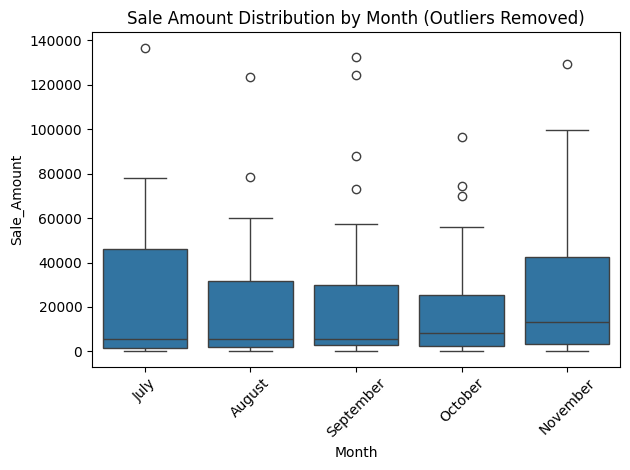

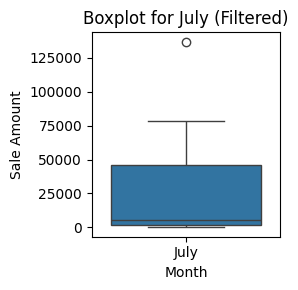

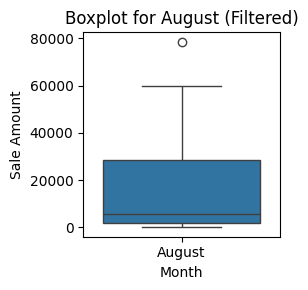

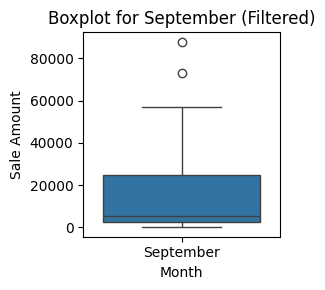

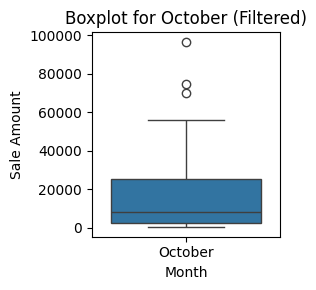

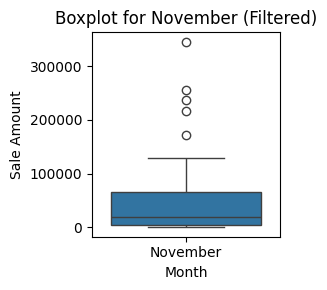

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Monthds = df['Month'].unique()

for ii in Monthds:
    df_month = df[df['Month'] == ii]

    Q1 = df_month['Sale_Amount'].quantile(0.25)
    Q3 = df_month['Sale_Amount'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR


    df_filtered = df_month[df_month['Sale_Amount'] < upper_bound]#upper_bound = outlier

    plt.figure(figsize=(3,3),dpi=100)
    sns.boxplot(x='Month', y='Sale_Amount', data=df_filtered)
    plt.title(f'Boxplot for {ii} (Filtered)')
    plt.xlabel('Month')
    plt.ylabel('Sale Amount')
    plt.tight_layout()
    plt.show()
